<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/MultiClass_Food_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary libraries


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn as sk
import keras as ks
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Tensorflow version :", tf.__version__)
print("Pandas version :", pd.__version__)
print("Numpy version :", np.__version__)
print("Keras Version :", ks.__version__)
print("Scikit-learn version :", sk.__version__)
print("Seaborn version :", sns.__version__)

Tensorflow version : 2.19.0
Pandas version : 2.2.2
Numpy version : 2.0.2
Keras Version : 3.13.2
Scikit-learn version : 1.6.1
Seaborn version : 0.13.2


## Creating necessary functions

In [ ]:
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  target_folder = target_dir+target_class

  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image Shapes: {img.shape}")

  return img

In [ ]:
def plot_loss_curve(history):
  """
  Returns separate loss curves for training and validation matrix
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  val_accuracy = history.history["val_accuracy"]
  accuracy = history.history["accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot Loss
  plt.figure()
  plt.plot(epochs, loss, label = "Training Loss")
  plt.plot(epochs, val_loss, label = "Val_Loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()
  # Plot Accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label = "Training Accuracy")
  plt.plot(epochs, val_accuracy, label = "Val_Accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Score")
  plt.legend()

In [ ]:
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor and reshapes it to (img_shape, img_shape, color channels)
  """
  img = tf.io.read_file(filename)
  img = tf.image.decode_image(img)
  img = tf.image.resize(img, size=[img_shape, img_shape])
  img = img/255
  return img

In [ ]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction with model and plots the image with the predicted class
  """
  img = load_and_prep_image(filename)
  pred = model.predict(tf.expand_dims(img, axis=0))
  if len(pred[0])>1 :
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred[0]))]
  plt.imshow()
  plt.title(f"Prediction : {pred_class}")
  plt.axis(False)

# Importing the dataset

In [ ]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2026-04-08 14:10:09--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 74.125.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   192MB/s    in 2.6s    

2026-04-08 14:10:12 (192 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in '10_food_classes_all_data'
There are 10 directories and 0 images in '10_food_classes_all_data/train'
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'
There are 1

In [ ]:
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [ ]:
import pathlib
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


['1113170.jpg']
Image Shapes: (512, 512, 3)


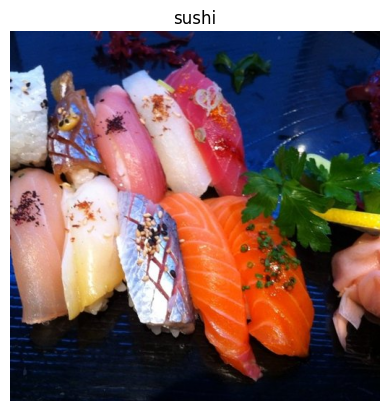

In [ ]:
import random
img = view_random_image(target_dir = train_dir,
                        target_class = random.choice(class_names))


# Preprocess the data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode="categorical")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224,224),
                                             batch_size=32,
                                             class_mode="categorical")


Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


# Baseline model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model_1 = Sequential([
    Conv2D(10,3,input_shape=(224,224,3), activation="relu"),
    Conv2D(10,3, activation="relu"),
    MaxPool2D(),
    Conv2D(10,3, activation="relu"),
    Conv2D(10,3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax")])

model_1.compile(loss="categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1 = model_1.fit(train_data,
                        epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.2261 - loss: 2.1322 - val_accuracy: 0.3212 - val_loss: 1.9541
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.3533 - loss: 1.8727 - val_accuracy: 0.3664 - val_loss: 1.8160
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.4779 - loss: 1.5484 - val_accuracy: 0.3684 - val_loss: 1.8234
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.6780 - loss: 0.9898 - val_accuracy: 0.3312 - val_loss: 2.2128
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8708 - loss: 0.4187 - val_accuracy: 0.3184 - val_loss: 2.9537


Clearly model_1 is overfitting

In [ ]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.3184 - loss: 2.9537


[2.9537353515625, 0.31839999556541443]

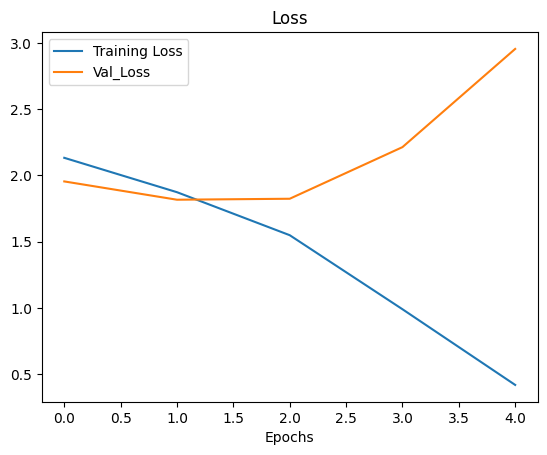

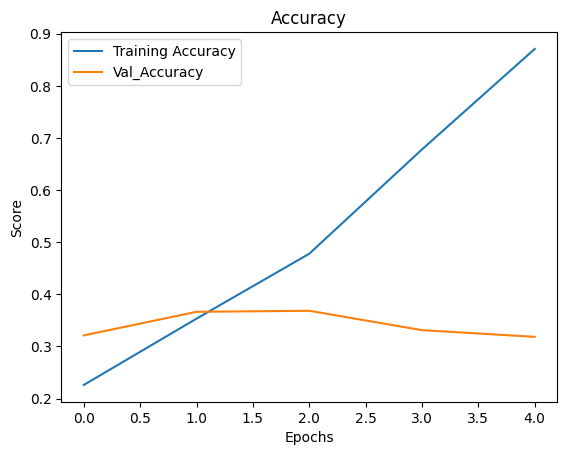

In [ ]:
plot_loss_curve(history_1)

Trying to improve the baseline model

1. Removing some layers

In [ ]:
model_2 = Sequential([
    Conv2D(10,3,input_shape=(224,224,3), activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax")
])

model_2.compile(loss="categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])


In [ ]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,800 (1.12 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps = len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 115ms/step - accuracy: 0.2420 - loss: 2.1611 - val_accuracy: 0.3264 - val_loss: 1.9710
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.3692 - loss: 1.8477 - val_accuracy: 0.2856 - val_loss: 1.9935
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 129ms/step - accuracy: 0.4781 - loss: 1.5837 - val_accuracy: 0.3400 - val_loss: 1.9424
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.6420 - loss: 1.1321 - val_accuracy: 0.3236 - val_loss: 2.0499
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8244 - loss: 0.6140 - val_accuracy: 0.3104 - val_loss: 2.3962


In [ ]:
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3104 - loss: 2.3962


[2.396238327026367, 0.31040000915527344]

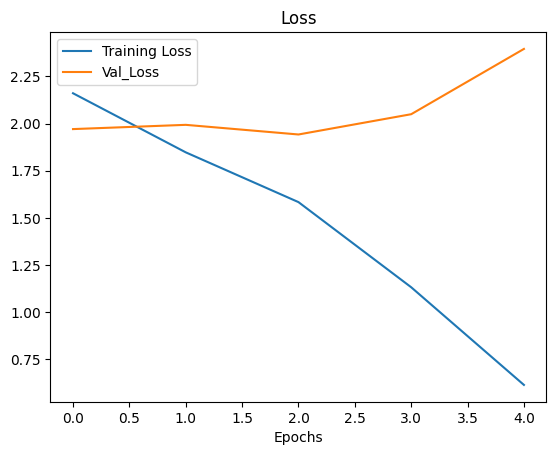

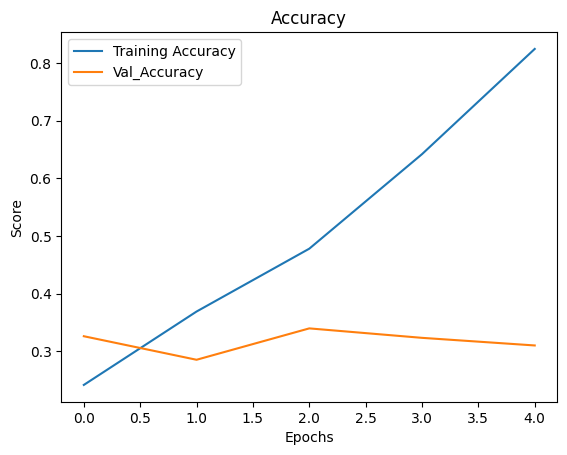

In [ ]:
plot_loss_curve(history_2)

Overfitting continues

2. Reducing overfitting by data augmentation

In [ ]:
# Create augmented data
train_datagen_augmented = ImageDataGenerator(rescale=1./255,
                                          rotation_range=0.2,
                                          width_shift_range=0.2,
                                          height_shift_range=0.2,
                                          zoom_range=0.2,
                                          horizontal_flip=True)
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               class_mode="categorical")


Found 7500 images belonging to 10 classes.


In [ ]:
model_3 = tf.keras.models.clone_model(model_2)
model_3.compile(loss="categorical_crossentropy",
                            optimizer="adam",
                            metrics=["accuracy"])

In [ ]:
history_3 = model_3.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.3349 - loss: 1.9050 - val_accuracy: 0.3824 - val_loss: 1.7651
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.3591 - loss: 1.8771 - val_accuracy: 0.3884 - val_loss: 1.7694
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.3564 - loss: 1.8711 - val_accuracy: 0.4268 - val_loss: 1.7065
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.3657 - loss: 1.8528 - val_accuracy: 0.3984 - val_loss: 1.7657
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - accuracy: 0.3767 - loss: 1.8284 - val_accuracy: 0.4164 - val_loss: 1.7279


In [ ]:
model_3.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 395ms/step - accuracy: 0.4164 - loss: 1.7279


[1.7279001474380493, 0.4163999855518341]

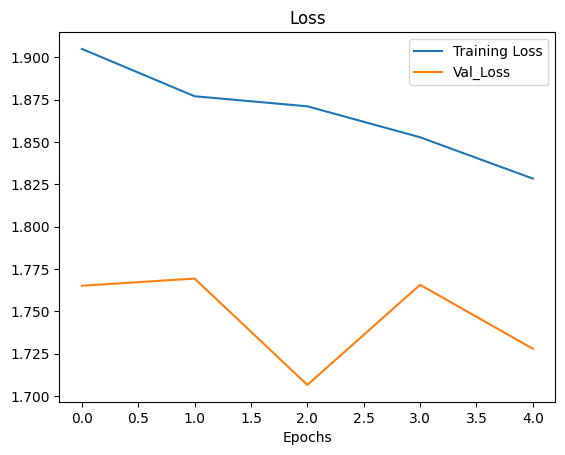

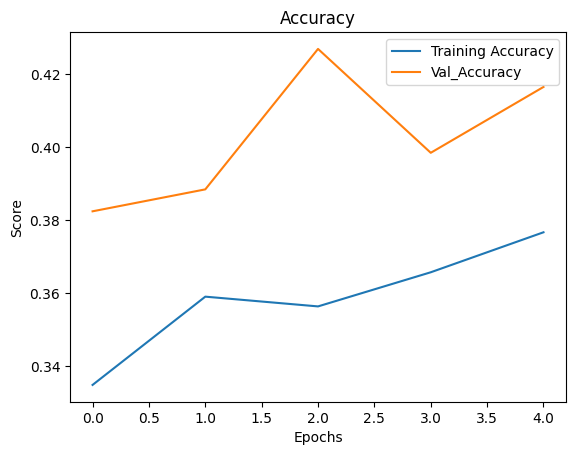

In [ ]:
plot_loss_curve(history_3)